In [1]:
import ROOT
import numpy as np
base_path = "/nfs/cms/arqolmo/SiWECALTB2026/Data/"
files ={"74":{"P4":f"{base_path}ecal_TB2026CERN_run_000046_dl.valcache.root",
              "P1":f"{base_path}ecal_TB2026CERN_run_000007_dl.valcache.root"},
        "52":{"P4":f"{base_path}ecal_TB2026CERN_run_000045_dl.valcache.root",
              "P1":f"{base_path}ecal_TB2026CERN_run_000013_dl.valcache.root"},
        "34":{"P4":f"{base_path}ecal_TB2026CERN_run_000044_dl.valcache.root",
              "P1":f"{base_path}ecal_TB2026CERN_run_000015_dl.valcache.root"},
        "20":{"P4":f"{base_path}ecal_TB2026CERN_run_000043_dl.valcache.root",
              "P1":f"{base_path}ecal_TB2026CERN_run_000020_dl.valcache.root"},
        "10":{"P4":f"{base_path}ecal_TB2026CERN_run_000042_dl.valcache.root",
              "P1":f"{base_path}ecal_TB2026CERN_run_000021_dl.valcache.root"},
        "7.5":{"P4":f"{base_path}ecal_TB2026CERN_run_000041_dl.valcache.root",
               "P1":f"{base_path}ecal_TB2026CERN_run_000022_dl.valcache.root"},
        
  }


In [2]:
# f = ROOT.TFile.Open(file)
quantile_val = 0.1
dl_filter = ("dl_score","dl_unmatched_fraction")
dfs_filtered = {}
for e in files:
  dfs_filtered[e] = {}
  for point in files[e].keys():
    df = ROOT.RDataFrame("ecal", files[e][point])
    df_filtered = df
    for filter in dl_filter:
      filter_vals = df.AsNumpy([filter])[filter]
      val = np.quantile(filter_vals, quantile_val)
      filter_key = f"{filter}<{val}"
      print(f"Energy {e} point {point} filter: {filter_key}")
      # print(f"Filter {filter_key}")
      df_filtered = df_filtered.Filter(filter_key)
    print(f"=== Energy {e} GeV")
    w_pass = df_filtered.Count().GetValue()
    w_total = df.Count().GetValue()
    print(f"Pass {w_pass} of {w_total} ({round(w_pass/w_total,3)}%)")
    dfs_filtered[e][point] = df_filtered

Energy 74 point P4 filter: dl_score<0.3652158886194229
Energy 74 point P4 filter: dl_unmatched_fraction<0.16258351504802704
=== Energy 74 GeV
Pass 5970 of 152660 (0.039%)
Energy 74 point P1 filter: dl_score<0.4476223587989807
Energy 74 point P1 filter: dl_unmatched_fraction<0.19480518996715546
=== Energy 74 GeV
Pass 245 of 6275 (0.039%)
Energy 52 point P4 filter: dl_score<0.4302784502506256
Energy 52 point P4 filter: dl_unmatched_fraction<0.13457076251506805
=== Energy 52 GeV
Pass 2151 of 51815 (0.042%)
Energy 52 point P1 filter: dl_score<0.4680932730436325
Energy 52 point P1 filter: dl_unmatched_fraction<0.1317073106765747
=== Energy 52 GeV
Pass 5628 of 154538 (0.036%)
Energy 34 point P4 filter: dl_score<0.5244343757629395
Energy 34 point P4 filter: dl_unmatched_fraction<0.12765957415103912
=== Energy 34 GeV
Pass 8697 of 149544 (0.058%)
Energy 34 point P1 filter: dl_score<0.5566946029663086
Energy 34 point P1 filter: dl_unmatched_fraction<0.12777778506278992
=== Energy 34 GeV
Pass 228

In [3]:
quantile_val = 0.1
dl_filter = ("dl_score", "dl_unmatched_fraction")
dfs_filtered = {}

for e in files:
    dfs_filtered[e] = {}
    for point in files[e].keys():
        df = ROOT.RDataFrame("ecal", files[e][point])
        
        df_new = df
        pass_cols = []
        for filt in dl_filter:
            filter_vals = df.AsNumpy([filt])[filt]
            val = np.quantile(filter_vals, quantile_val)
            cond = f"{filt}<{val}"
            col_name = f"pass_{filt}"
            print(f"Energy {e} point {point} filter: {cond} -> column {col_name}")
            df_new = df_new.Define(col_name, cond)
            pass_cols.append(col_name)
        
        # columna combinada opcional, con el AND de todas
        df_new = df_new.Define("pass_all", " && ".join(pass_cols))
        
        print(f"=== Energy {e} GeV")
        w_pass = df_new.Filter("pass_all").Count().GetValue()
        w_total = df_new.Count().GetValue()
        print(f"Pass {w_pass} of {w_total} ({round(w_pass/w_total,3)}%)")
        
        dfs_filtered[e][point] = df_new

Energy 74 point P4 filter: dl_score<0.3652158886194229 -> column pass_dl_score
Energy 74 point P4 filter: dl_unmatched_fraction<0.16258351504802704 -> column pass_dl_unmatched_fraction
=== Energy 74 GeV
Pass 5970 of 152660 (0.039%)
Energy 74 point P1 filter: dl_score<0.4476223587989807 -> column pass_dl_score
Energy 74 point P1 filter: dl_unmatched_fraction<0.19480518996715546 -> column pass_dl_unmatched_fraction
=== Energy 74 GeV
Pass 245 of 6275 (0.039%)
Energy 52 point P4 filter: dl_score<0.4302784502506256 -> column pass_dl_score
Energy 52 point P4 filter: dl_unmatched_fraction<0.13457076251506805 -> column pass_dl_unmatched_fraction
=== Energy 52 GeV
Pass 2151 of 51815 (0.042%)
Energy 52 point P1 filter: dl_score<0.4680932730436325 -> column pass_dl_score
Energy 52 point P1 filter: dl_unmatched_fraction<0.1317073106765747 -> column pass_dl_unmatched_fraction
=== Energy 52 GeV
Pass 5628 of 154538 (0.036%)
Energy 34 point P4 filter: dl_score<0.5244343757629395 -> column pass_dl_scor

In [4]:
df.GetColumnNames()

vector<string>{ "bar_r", "bar_x", "bar_y", "bcid", "dl_beam_energy", "dl_cardinality_delta", "dl_cardinality_error", "dl_cardinality_ratio", "dl_energy_error", "dl_n_true", "dl_score", "dl_unmatched_fraction", "e_over_nhit", "energy", "energy_per_layer", "event", "first_layer", "hit_X0", "hit_chan", "hit_chip", "hit_energy", "hit_hg", "hit_lg", "hit_sca", "hit_slab", "hit_w_energy", "hit_x", "hit_y", "hit_z", "hits_per_layer", "is_shower", "last_layer", "mip_likeness", "moliere", "n_hit", "n_layers_hit", "nhit", "nhit_chan", "nhit_chip", "nhit_slab", "run", "shower_end", "shower_end_10", "shower_length", "shower_max", "shower_start", "shower_start_10", "spill", "sum_energy", "sum_hg", "transverse_rms", "weighte", "weighte_per_layer", "zbary" }

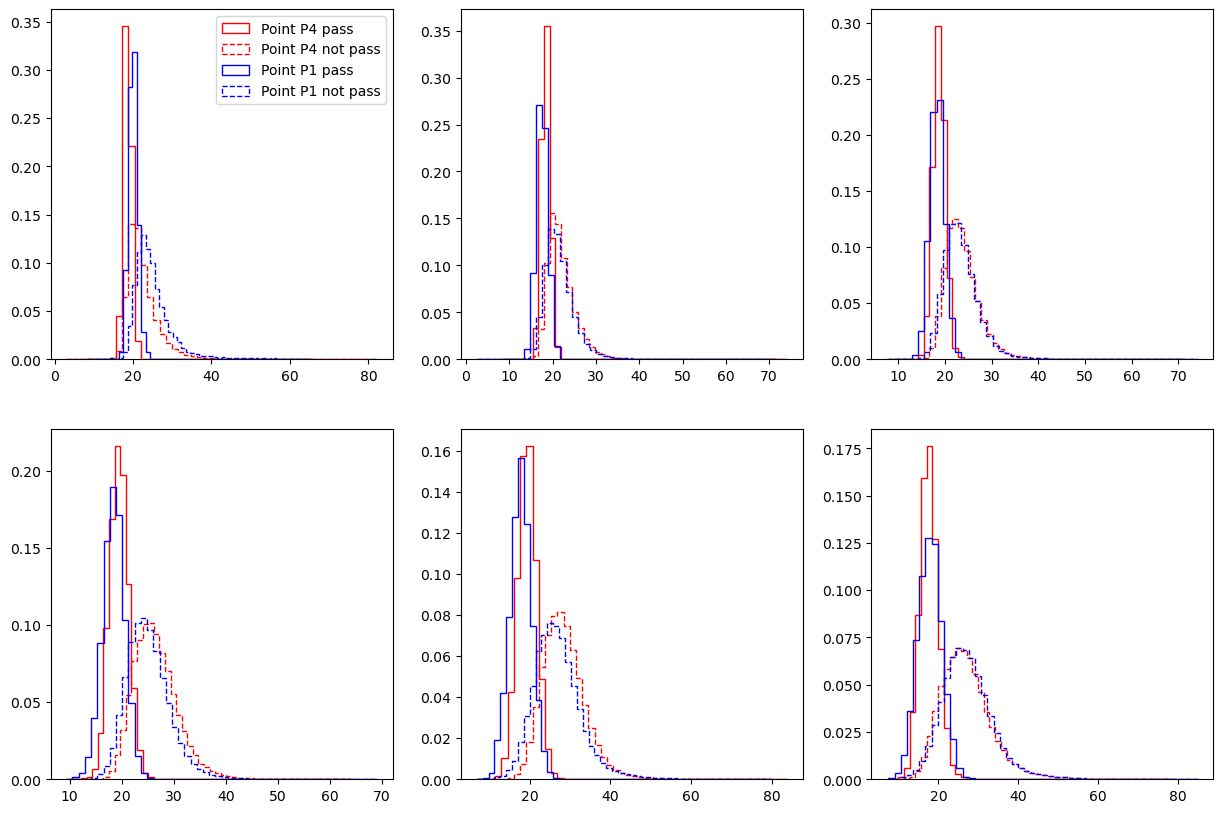

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
max_range = [800, 800, 600, 500, 400, 250]
colors_point = ["red", "blue"]
column_to_plot = "transverse_rms"
for i, e in enumerate(dfs_filtered):
  fig = plt.subplot(2,3,i+1)
  
  for j, point in enumerate(dfs_filtered[e]):
    df = dfs_filtered[e][point]
    val_pass = df.Filter("pass_all").AsNumpy([column_to_plot])[column_to_plot]
    val_not_pass = df.Filter("not pass_all").AsNumpy([column_to_plot])[column_to_plot]
    maximum = max(max(val_not_pass), max(val_pass))
    minimum = min(min(val_not_pass), min(val_pass))
    plt.hist(val_pass,
             bins=50,
             range=(minimum, maximum),
             label=f"Point {point} pass",
             color=colors_point[j], histtype="step", density=True)
    plt.hist(val_not_pass,
             bins=50,
             range=(minimum, maximum),
             label=f"Point {point} not pass",
             color=colors_point[j], histtype="step", linestyle=("dashed"), density=True)
  if i == 0:
    plt.legend()

In [28]:
cols = ["dl_score", "dl_unmatched_fraction", "zbary", "e_over_nhit", "energy", "mip_likeness", "moliere", "n_hit", "pass_all"]
nn_cols = ["dl_cardinality_delta", "dl_cardinality_error", "dl_cardinality_ratio", "dl_energy_error","pass_all","dl_n_true", "dl_score", "dl_unmatched_fraction"]

In [7]:
import pandas as pd

df_dict = {}
df_dict["energy_lbl"] = []
df_dict["point"] = []

for i, e in enumerate(dfs_filtered):
    for j, point in enumerate(dfs_filtered[e]):
        n_rows = None
        for column in cols:
            col_np = dfs_filtered[e][point].AsNumpy([column])[column]
            if column not in df_dict:
                df_dict[column] = []
            df_dict[column].extend(col_np)
            n_rows = len(col_np)  # todas las columnas tienen el mismo tamaño

        # esto va FUERA del bucle de columnas
        df_dict["energy_lbl"].extend([e] * n_rows)
        df_dict["point"].extend([point] * n_rows)

df = pd.DataFrame(df_dict)

In [29]:
import pandas as pd

df_dict = {}
df_dict["energy_lbl"] = []
df_dict["point"] = []

for i, e in enumerate(dfs_filtered):
    for j, point in enumerate(dfs_filtered[e]):
        n_rows = None
        for column in nn_cols:
            col_np = dfs_filtered[e][point].AsNumpy([column])[column]
            if column not in df_dict:
                df_dict[column] = []
            df_dict[column].extend(col_np)
            n_rows = len(col_np)  # todas las columnas tienen el mismo tamaño

        # esto va FUERA del bucle de columnas
        df_dict["energy_lbl"].extend([e] * n_rows)
        df_dict["point"].extend([point] * n_rows)

df_nn = pd.DataFrame(df_dict)

In [8]:
import pandas.plotting as pdp

In [9]:
# plot_cols = df.select_dtypes(include="number").columns
# c = df["pass_all"]
# pdp.scatter_matrix(df[plot_cols], marker="o", alpha=0.4, c = c)
# plt.show()

In [ ]:
df_sample = df.sample(n=50_000, random_state=0)
plot_cols = df_sample.select_dtypes(include="number").columns
# pdp.scatter_matrix(df_sample[plot_cols], marker="o", alpha=0.4, c=df_sample["pass_all"], figsize=(20,20))
# plt.figure(figsize=(50,50))
# plt.show()
import seaborn as sns
sns.pairplot(df_sample, vars=plot_cols, hue="pass_all", kind="hist", corner=True)

In [ ]:
sns.pairplot(df_sample, vars=plot_cols, hue="energy_lbl", kind="hist", corner=True)

In [ ]:
df_sample["group"] = df_sample["energy_lbl"].astype(str) + "_" + df_sample["point"].astype(str)
sns.pairplot(df_sample, vars=plot_cols, hue="group", kind="hist", corner=True)

In [ ]:
g = sns.FacetGrid(df_sample, col="energy_lbl", row="point", hue="pass_all", margin_titles=True)
g.map(sns.scatterplot, "dl_score", "e_over_nhit", alpha=0.4)
g.add_legend()

In [ ]:
df_melt = df_sample.melt(id_vars=["energy_lbl", "point"], value_vars=[c for c in plot_cols if c not in ("energy_lbl","point")])
g = sns.FacetGrid(df_melt, col="variable", col_wrap=4, sharex=False, sharey=False)
g.map_dataframe(sns.boxplot, x="energy_lbl", y="value", hue="point", palette="tab10")
g.add_legend()
plt.show()

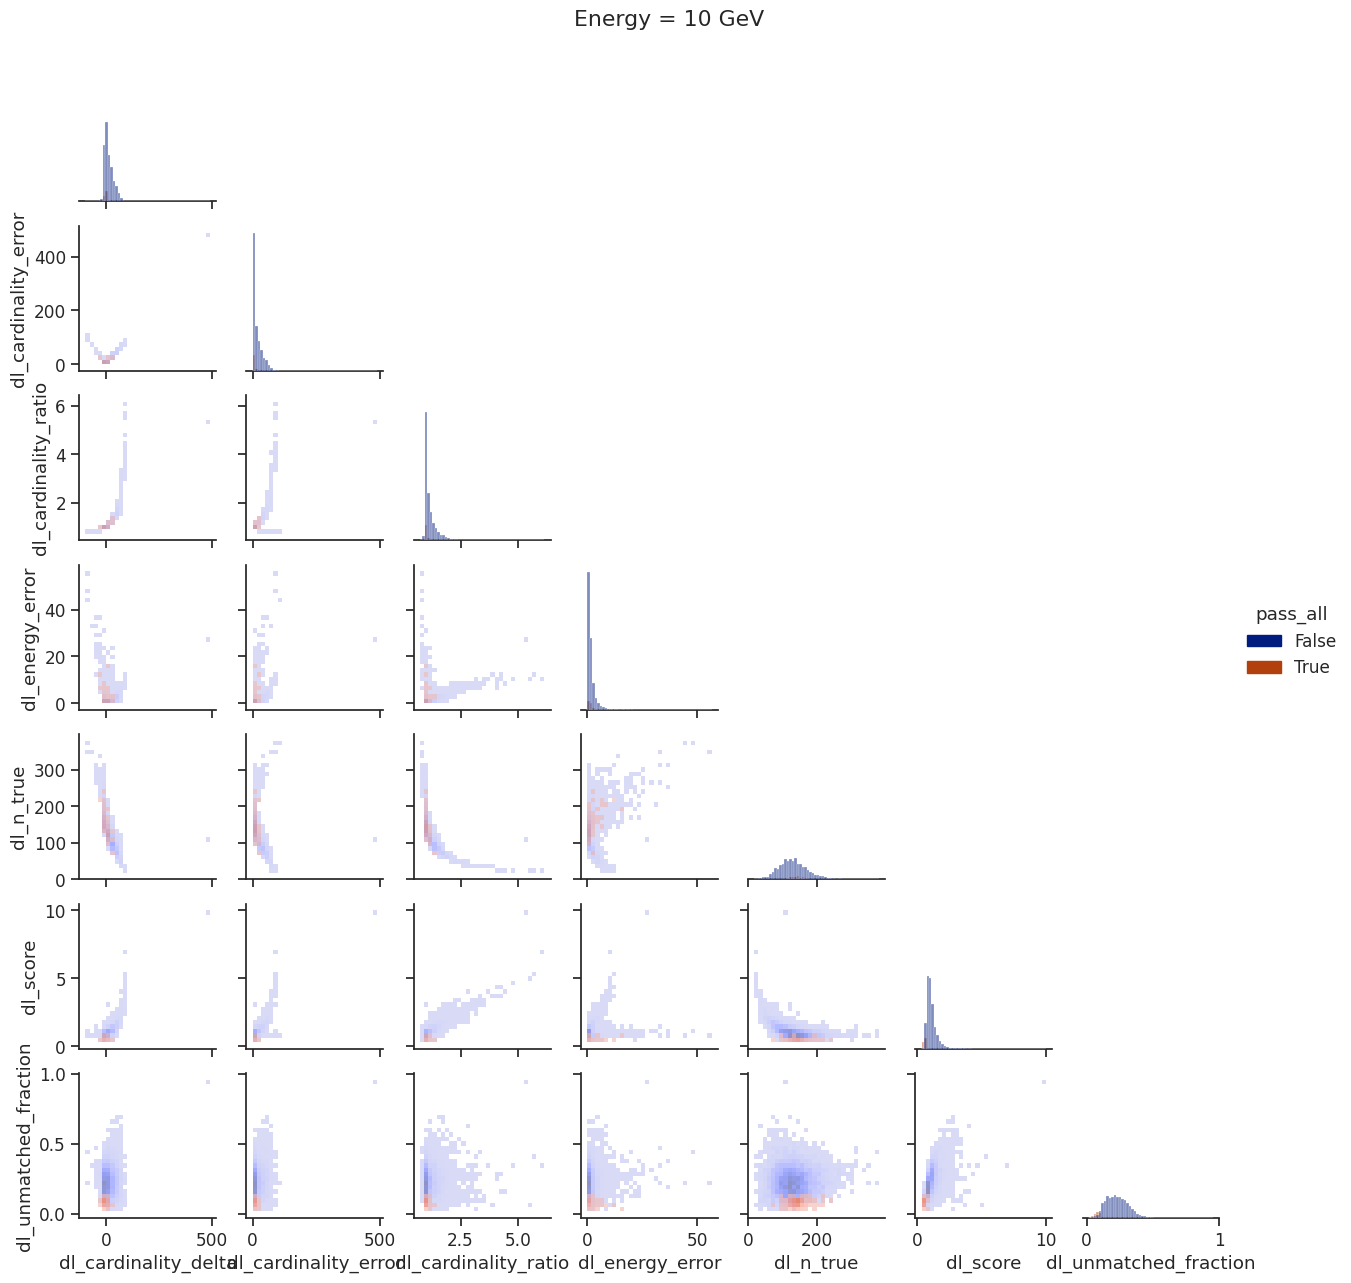

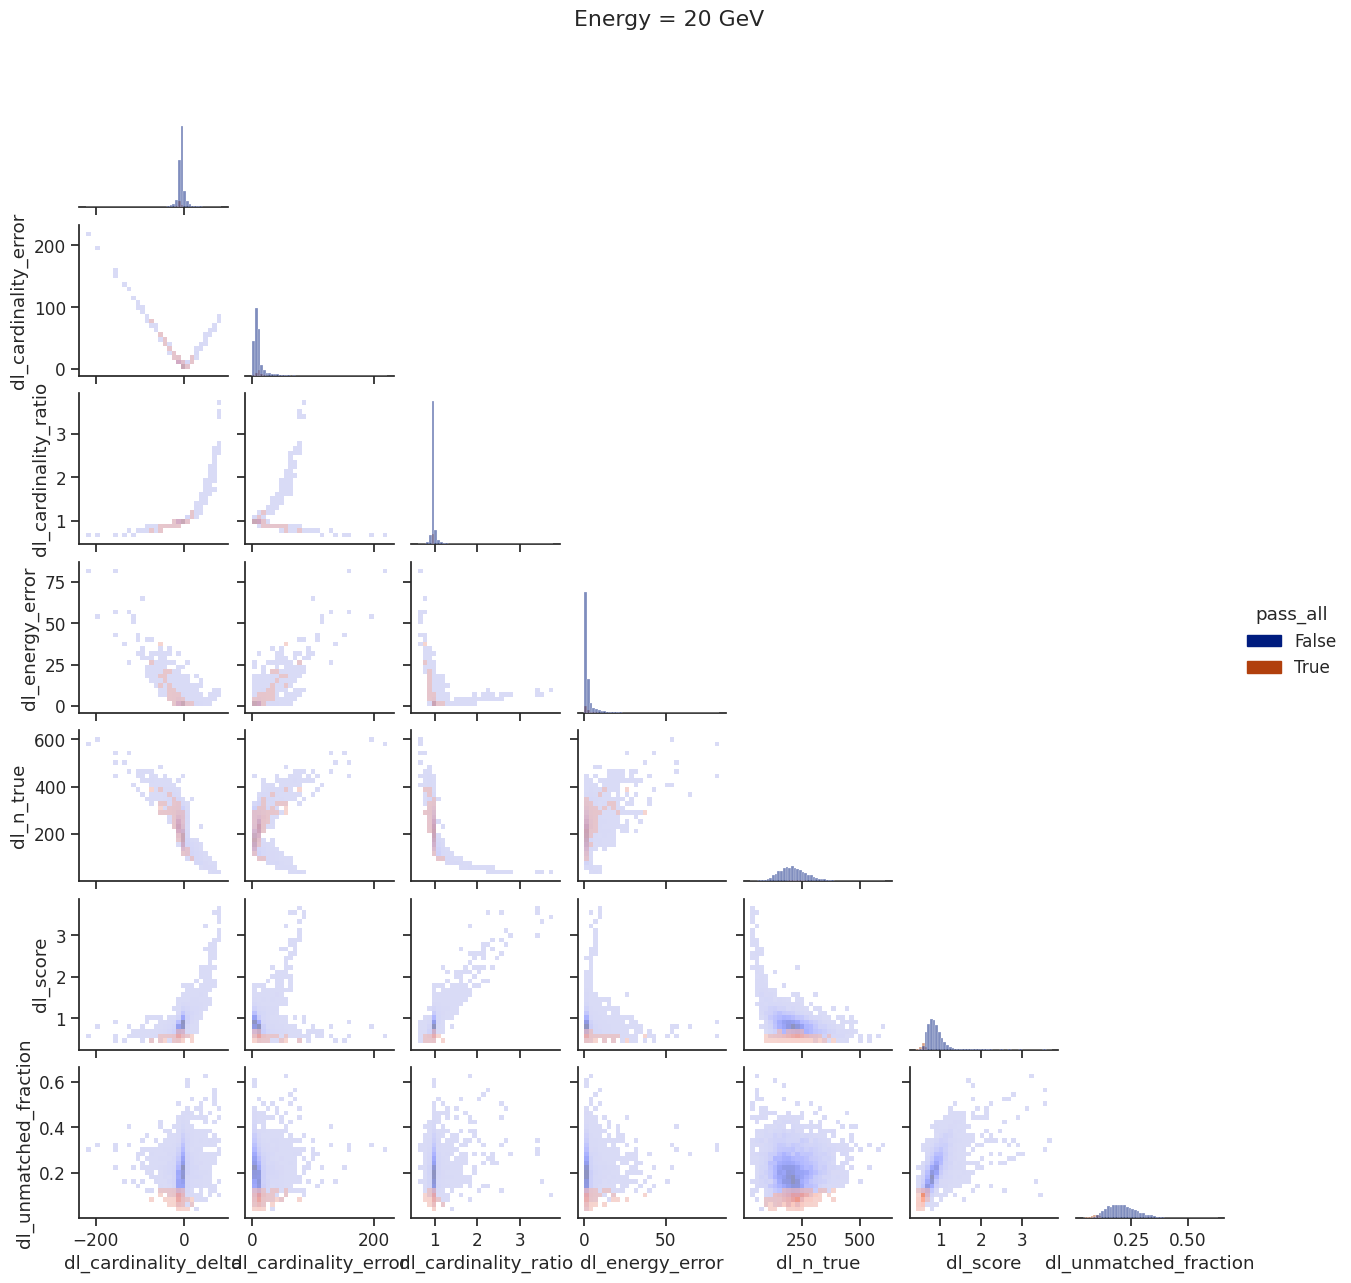

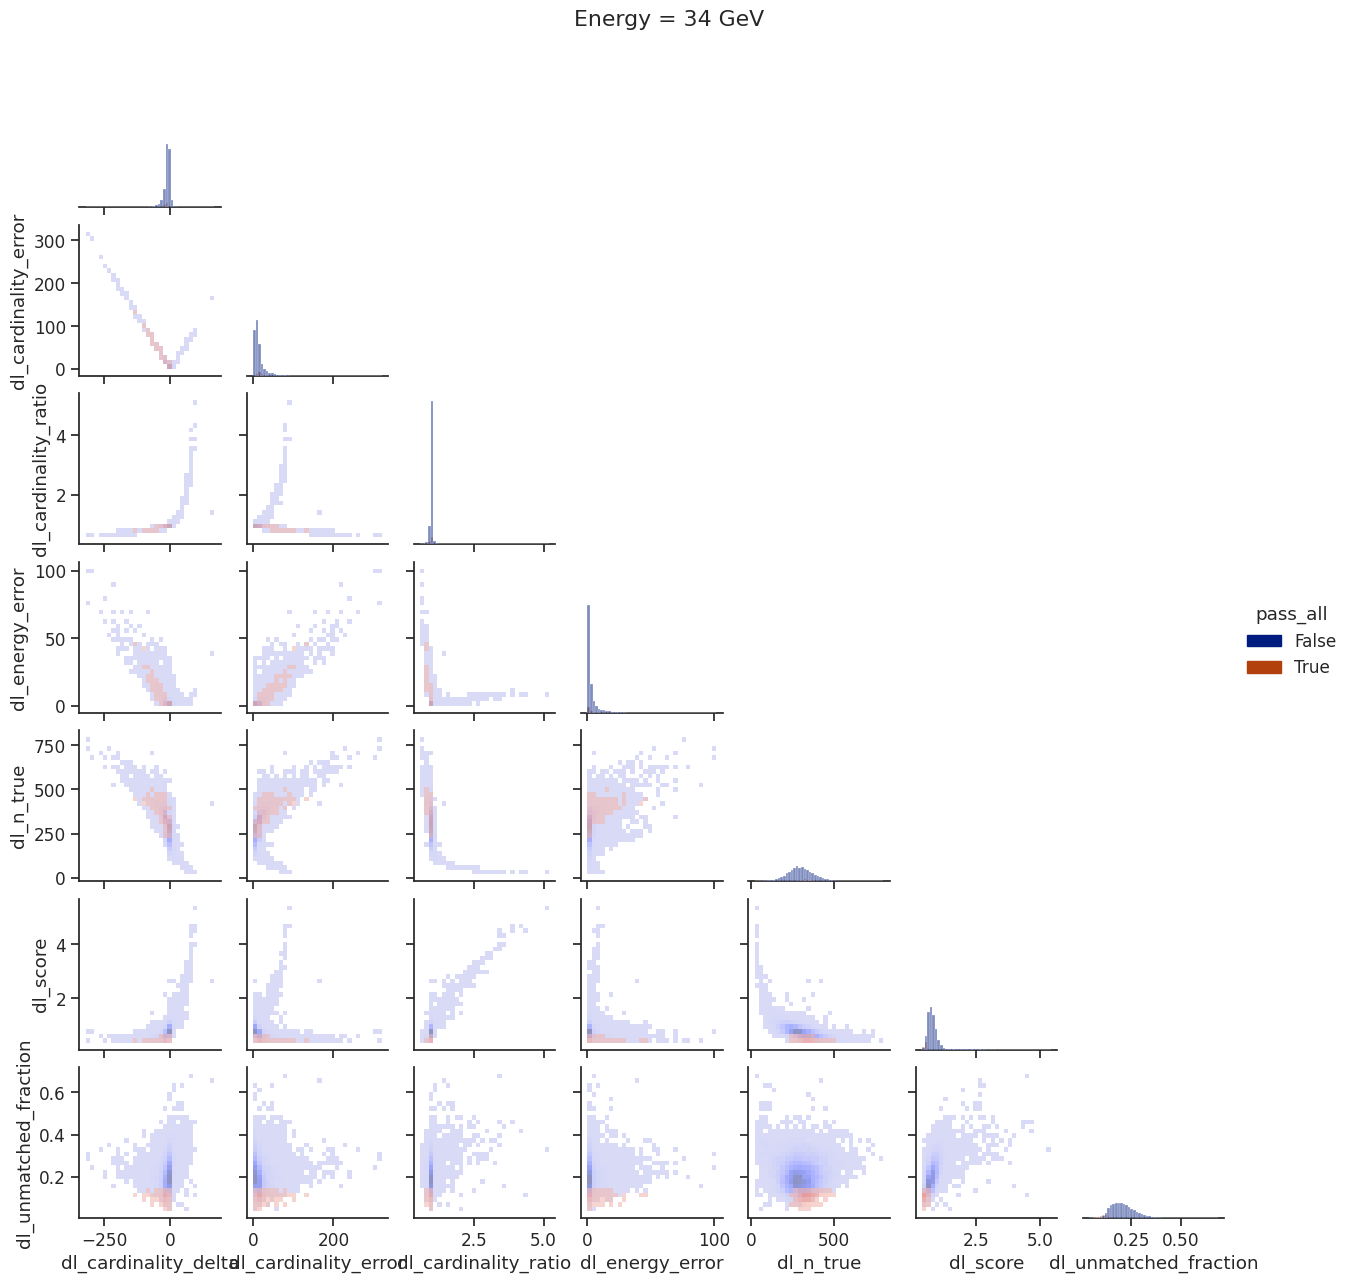

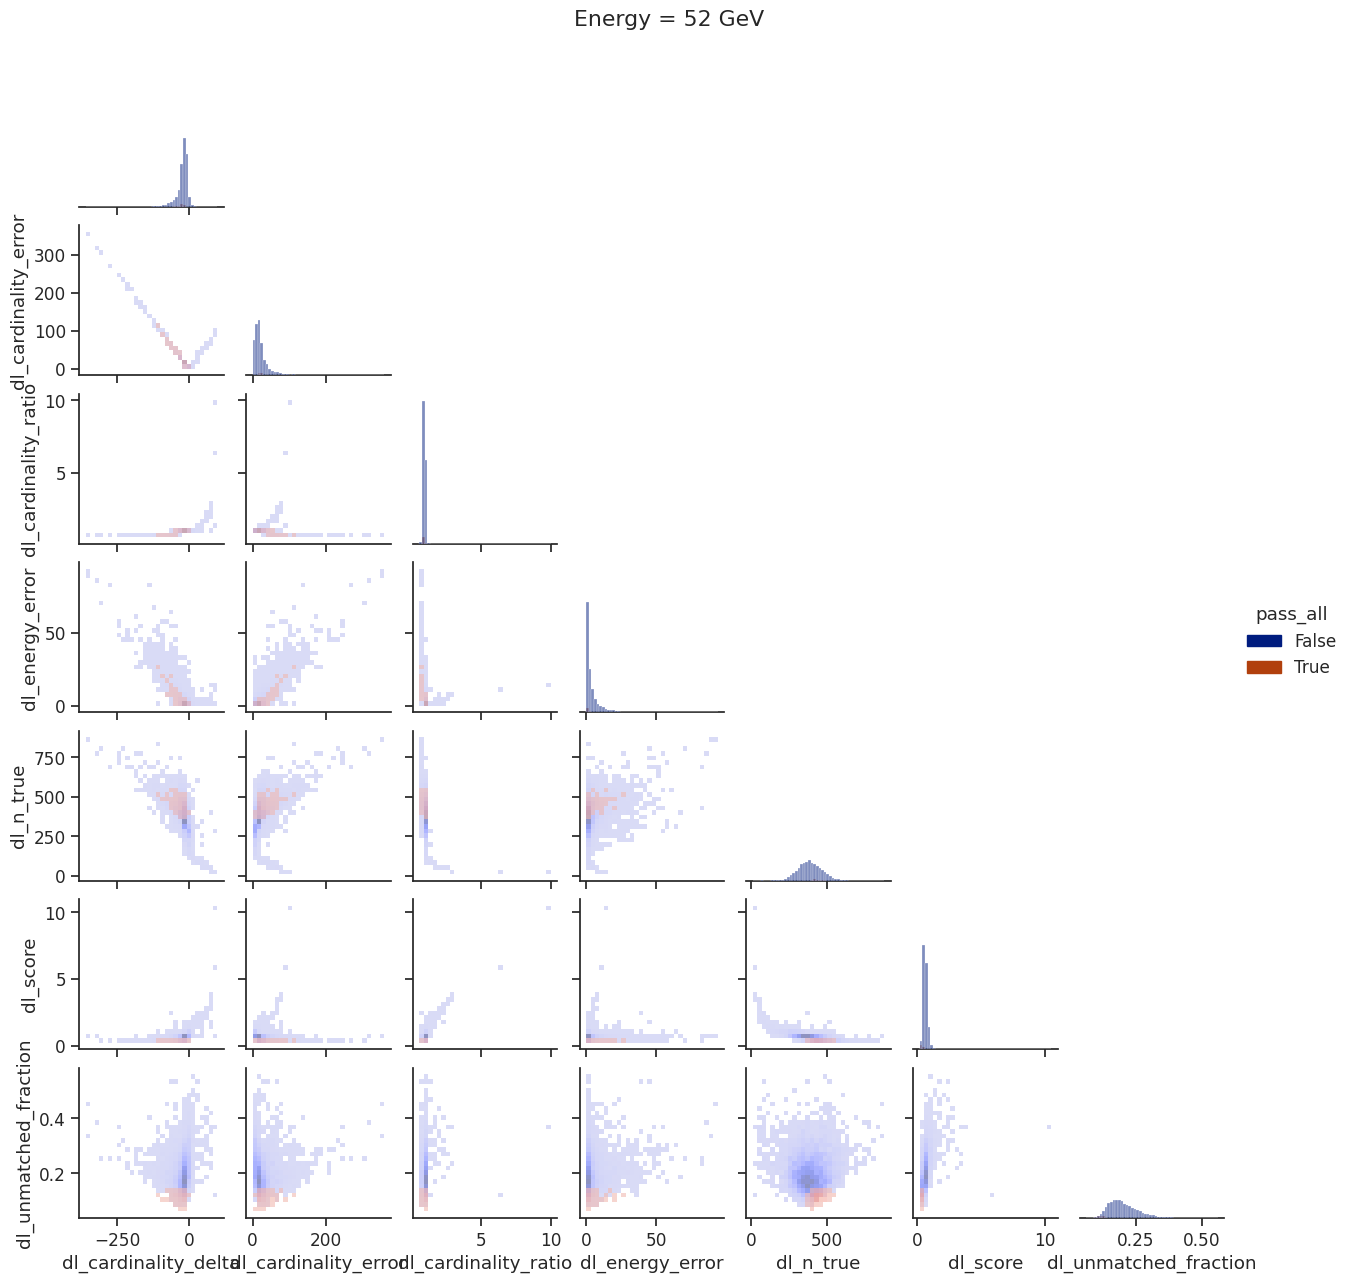

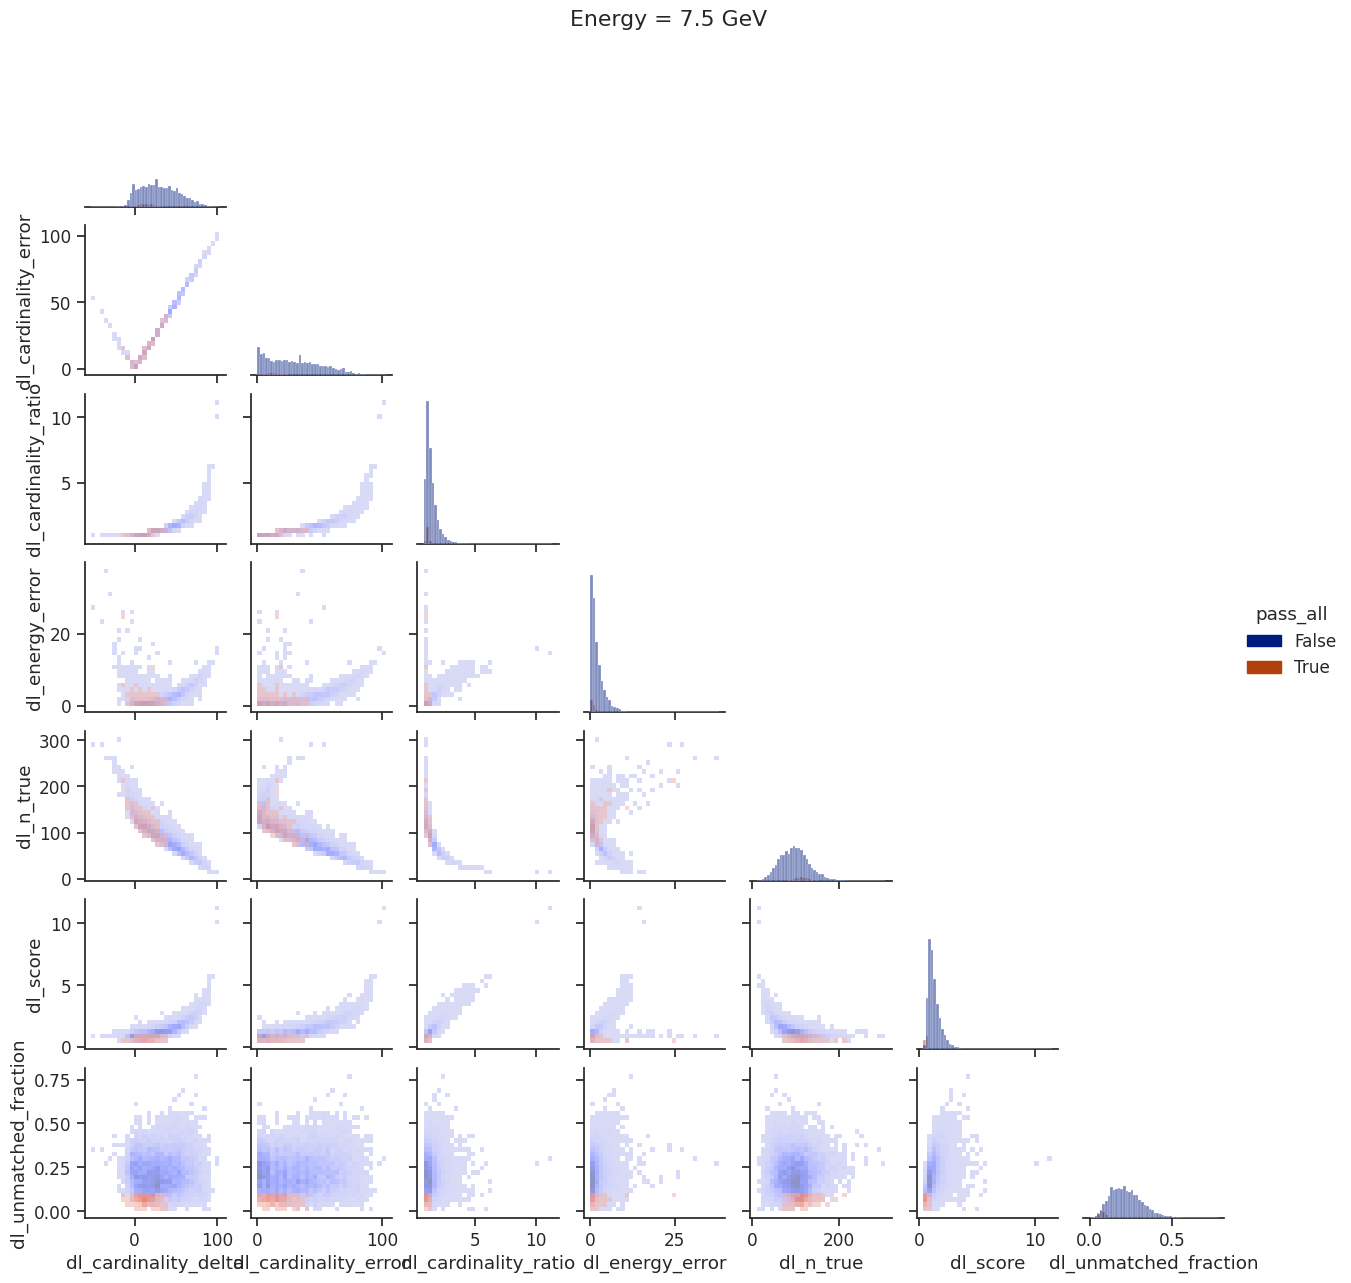

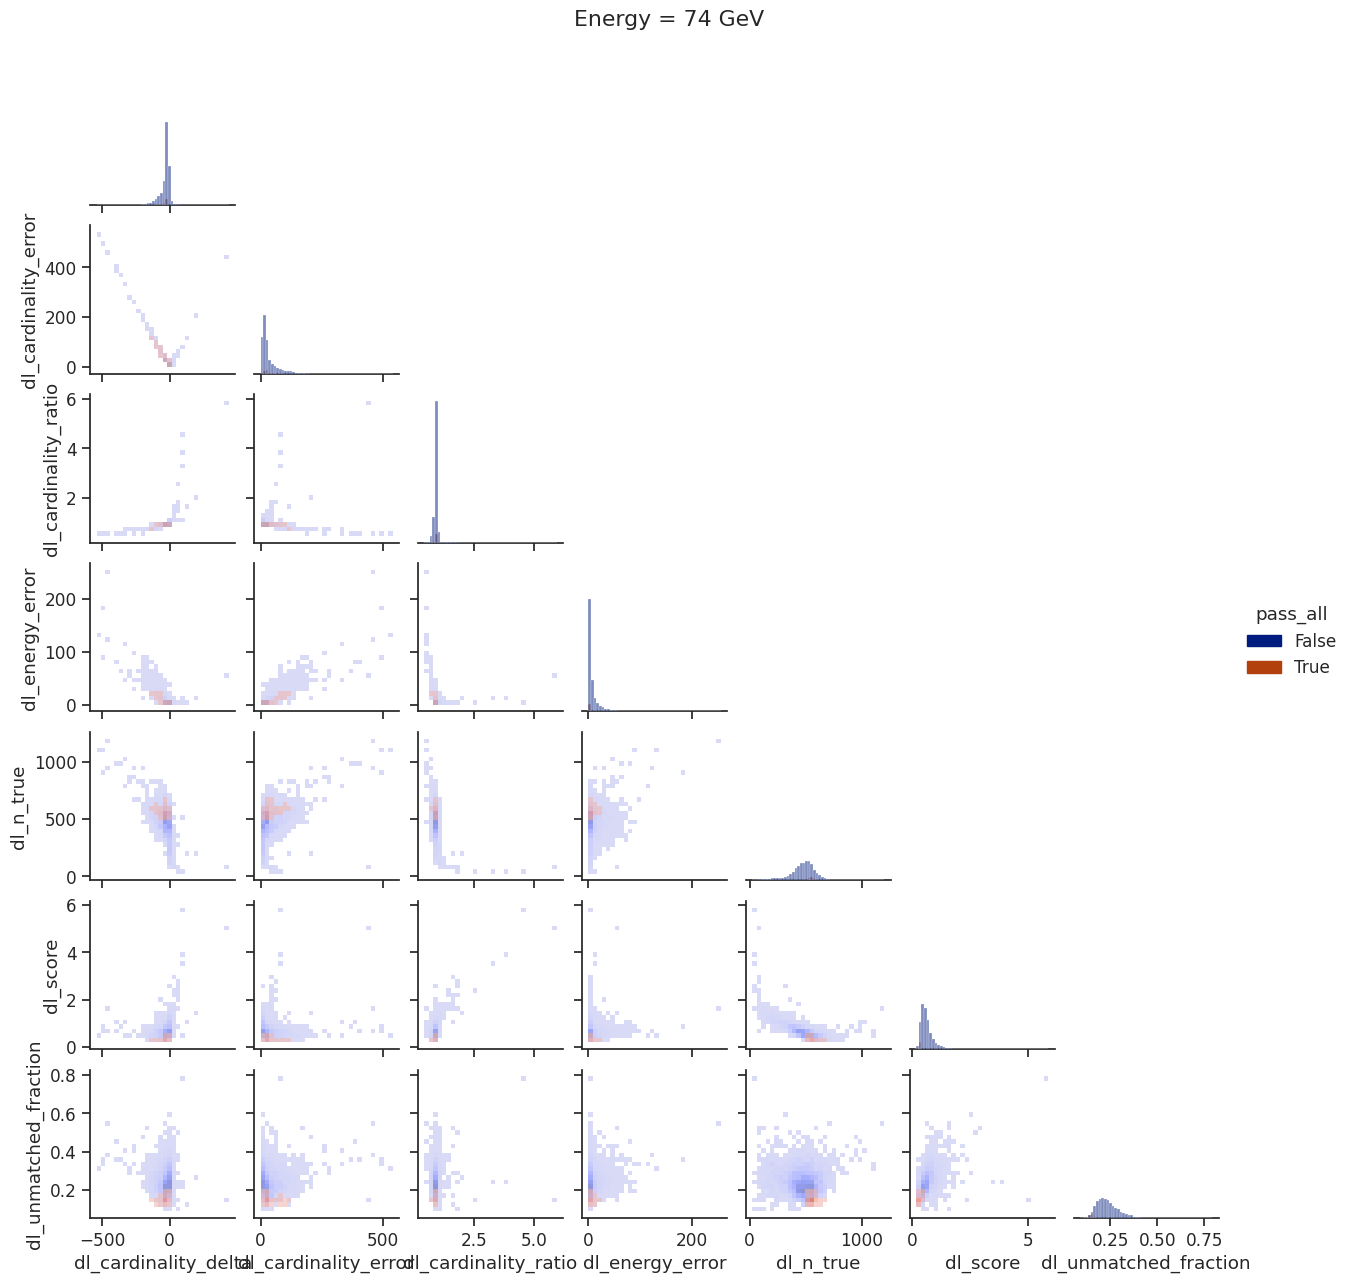

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="ticks", palette="dark", context="notebook", font_scale=1.1)
# sns.set_theme()
df_sample_nn = df_nn.sample(n=50_000, random_state=0)
plot_cols = df_sample_nn.select_dtypes(include="number").columns
plot_cols = [c for c in plot_cols if c != "pass_all"]  # que no se repita como variable

for e in sorted(df_sample_nn["energy_lbl"].unique()):
    df_e = df_sample_nn[df_sample_nn["energy_lbl"] == e]
    g = sns.pairplot(df_e, vars=plot_cols, hue="pass_all", kind="hist", corner=True,
                      plot_kws={"alpha": 0.6, "bins":30}, diag_kws={"bins":50},height=1.8)
    g.figure.suptitle(f"Energy = {e} GeV", y=1.02)
    plt.show()

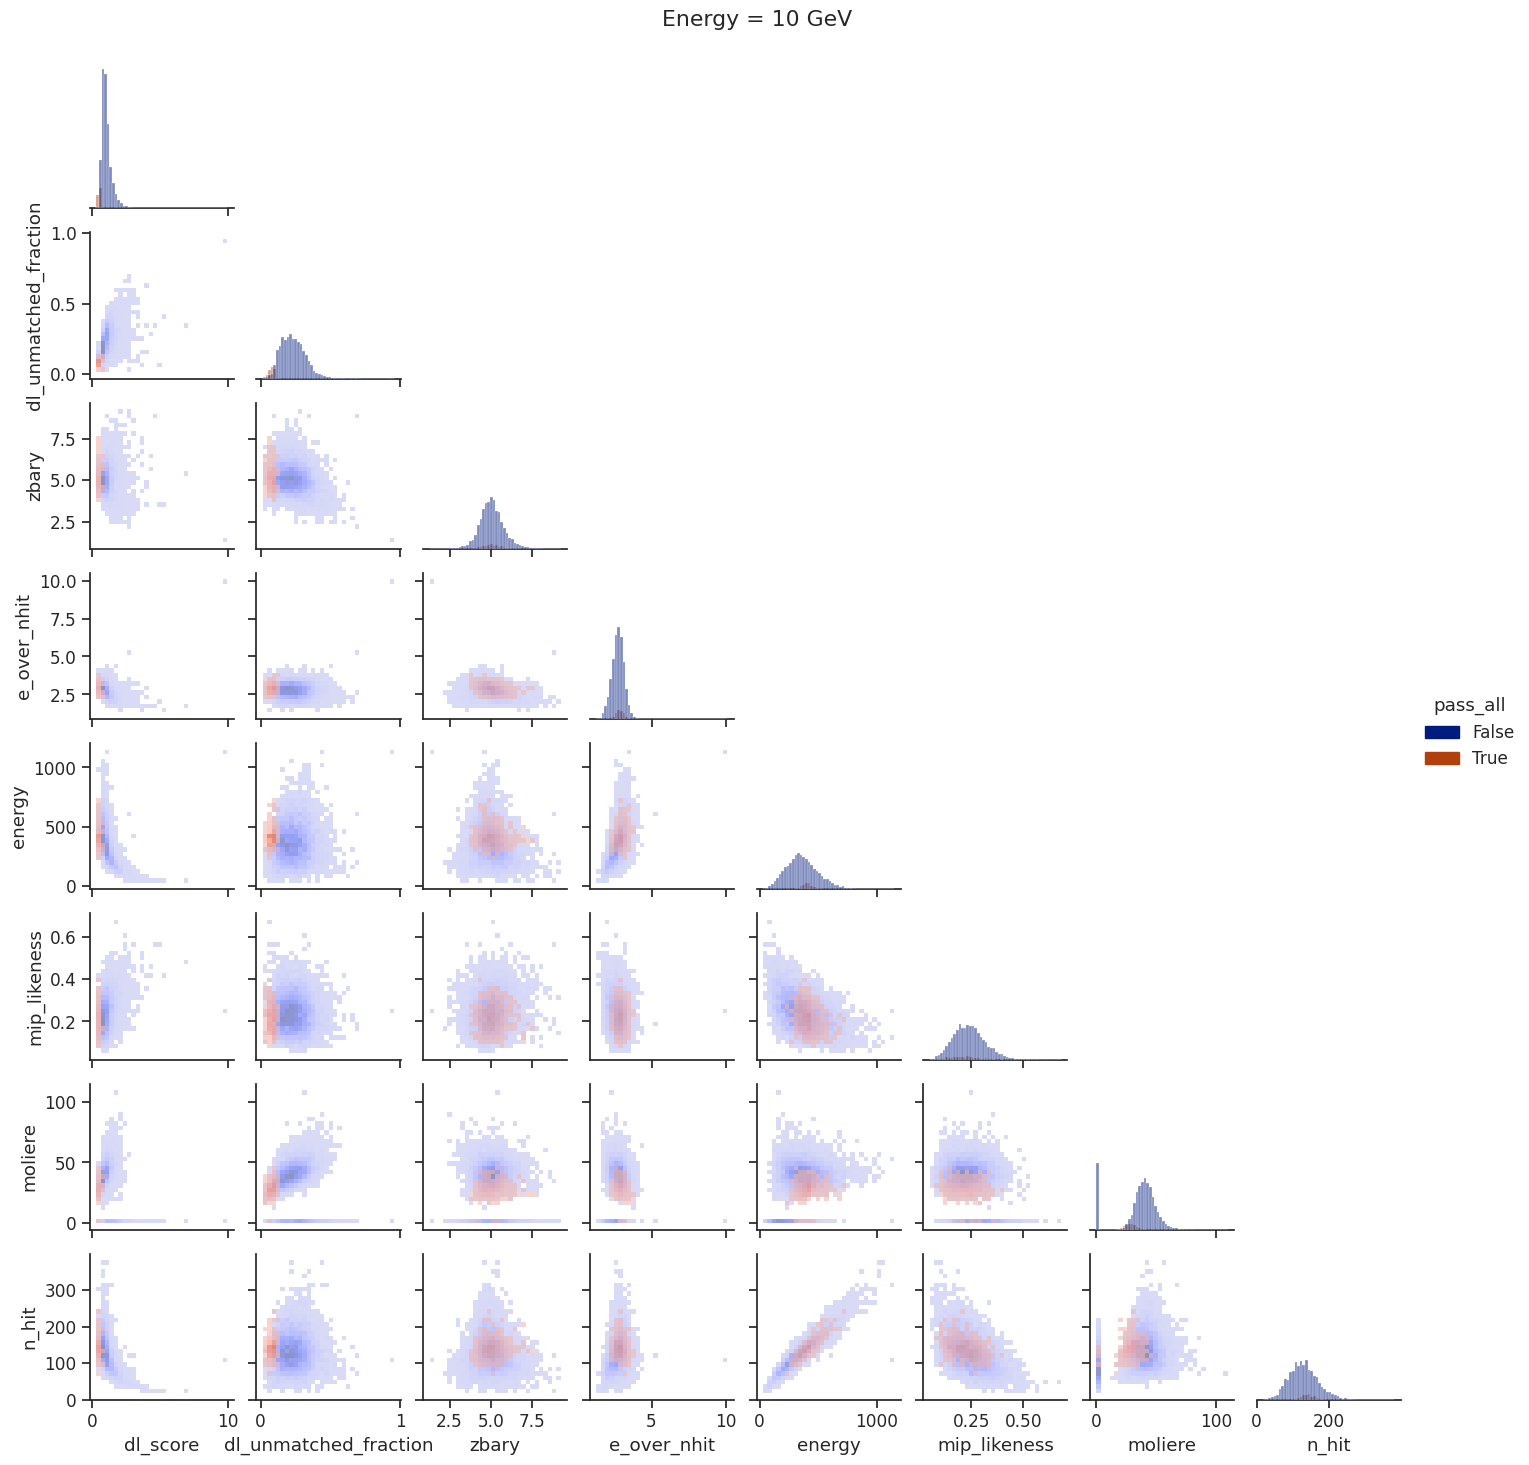

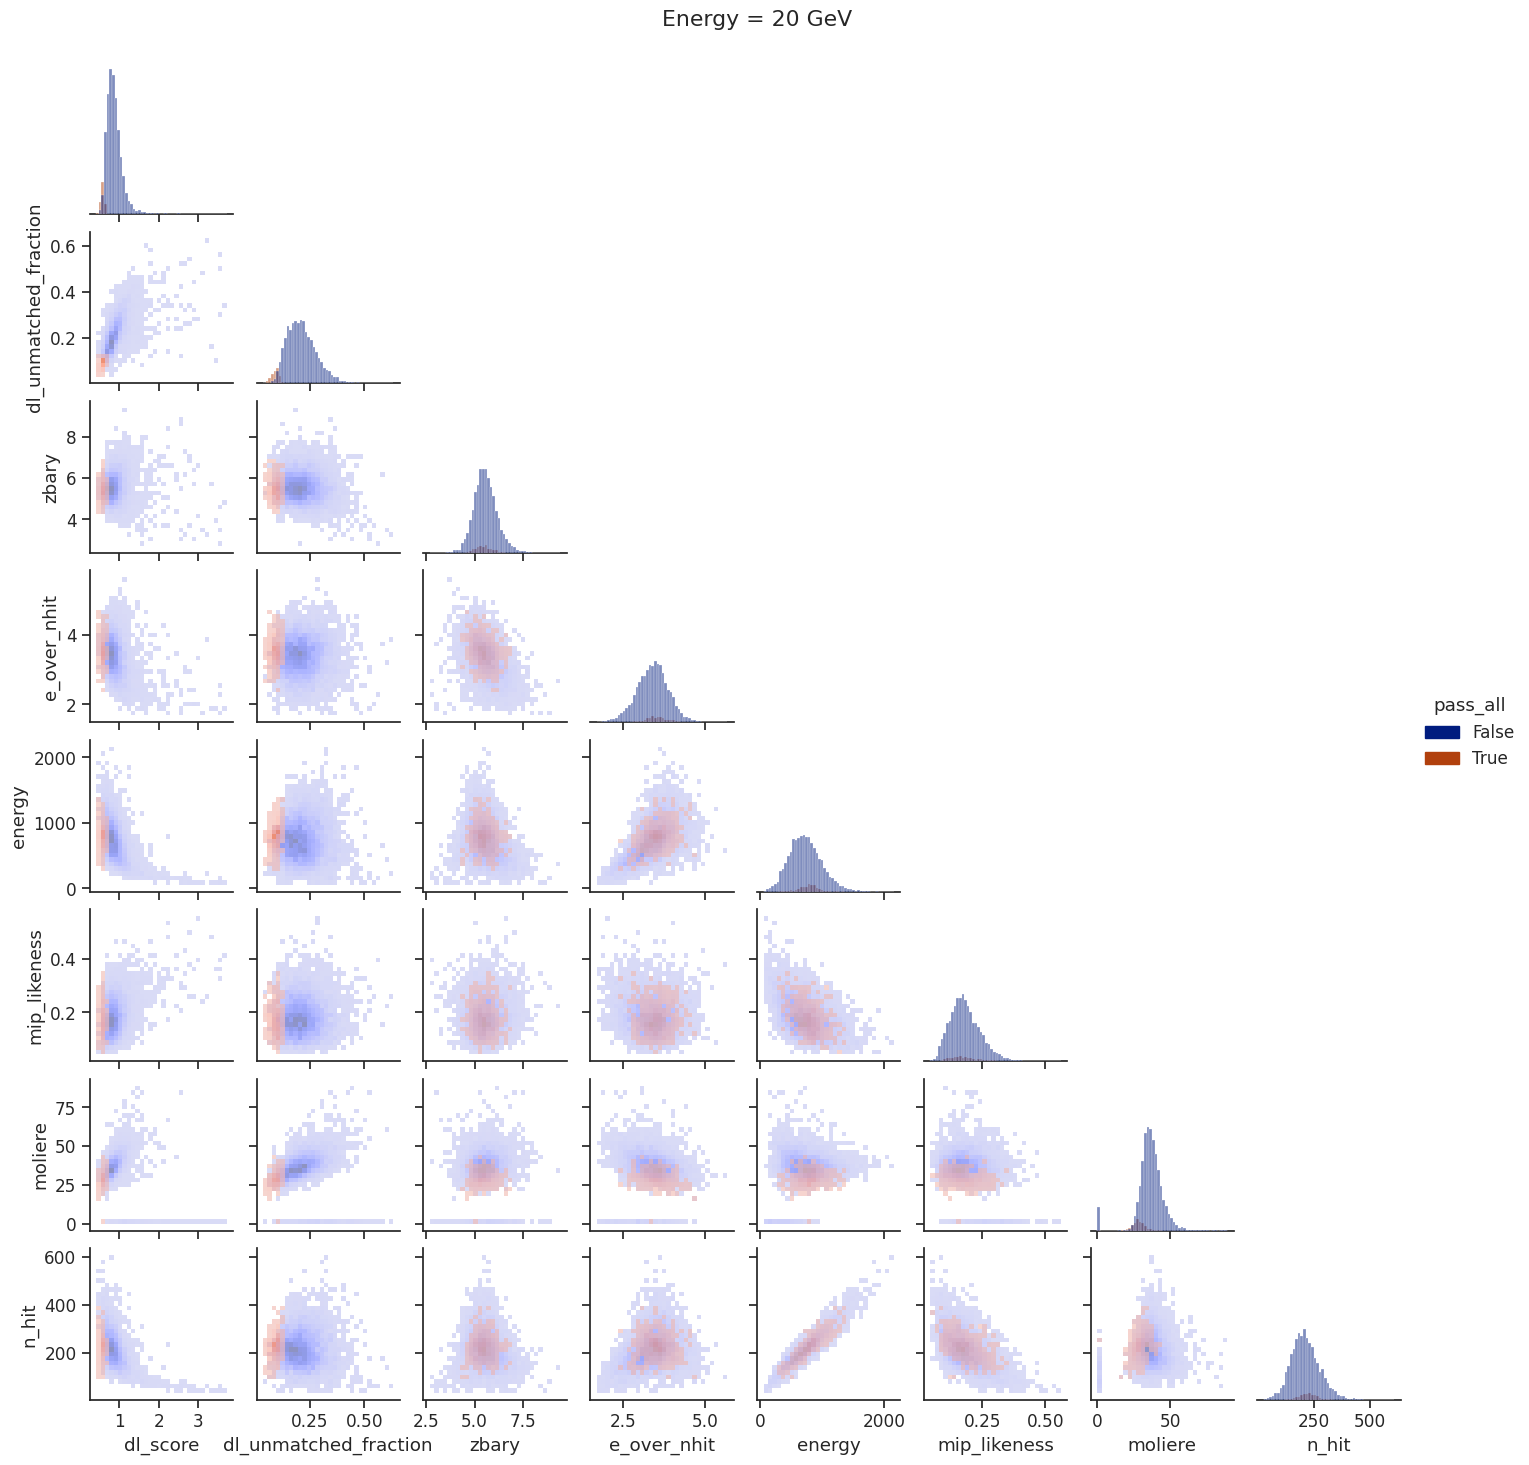

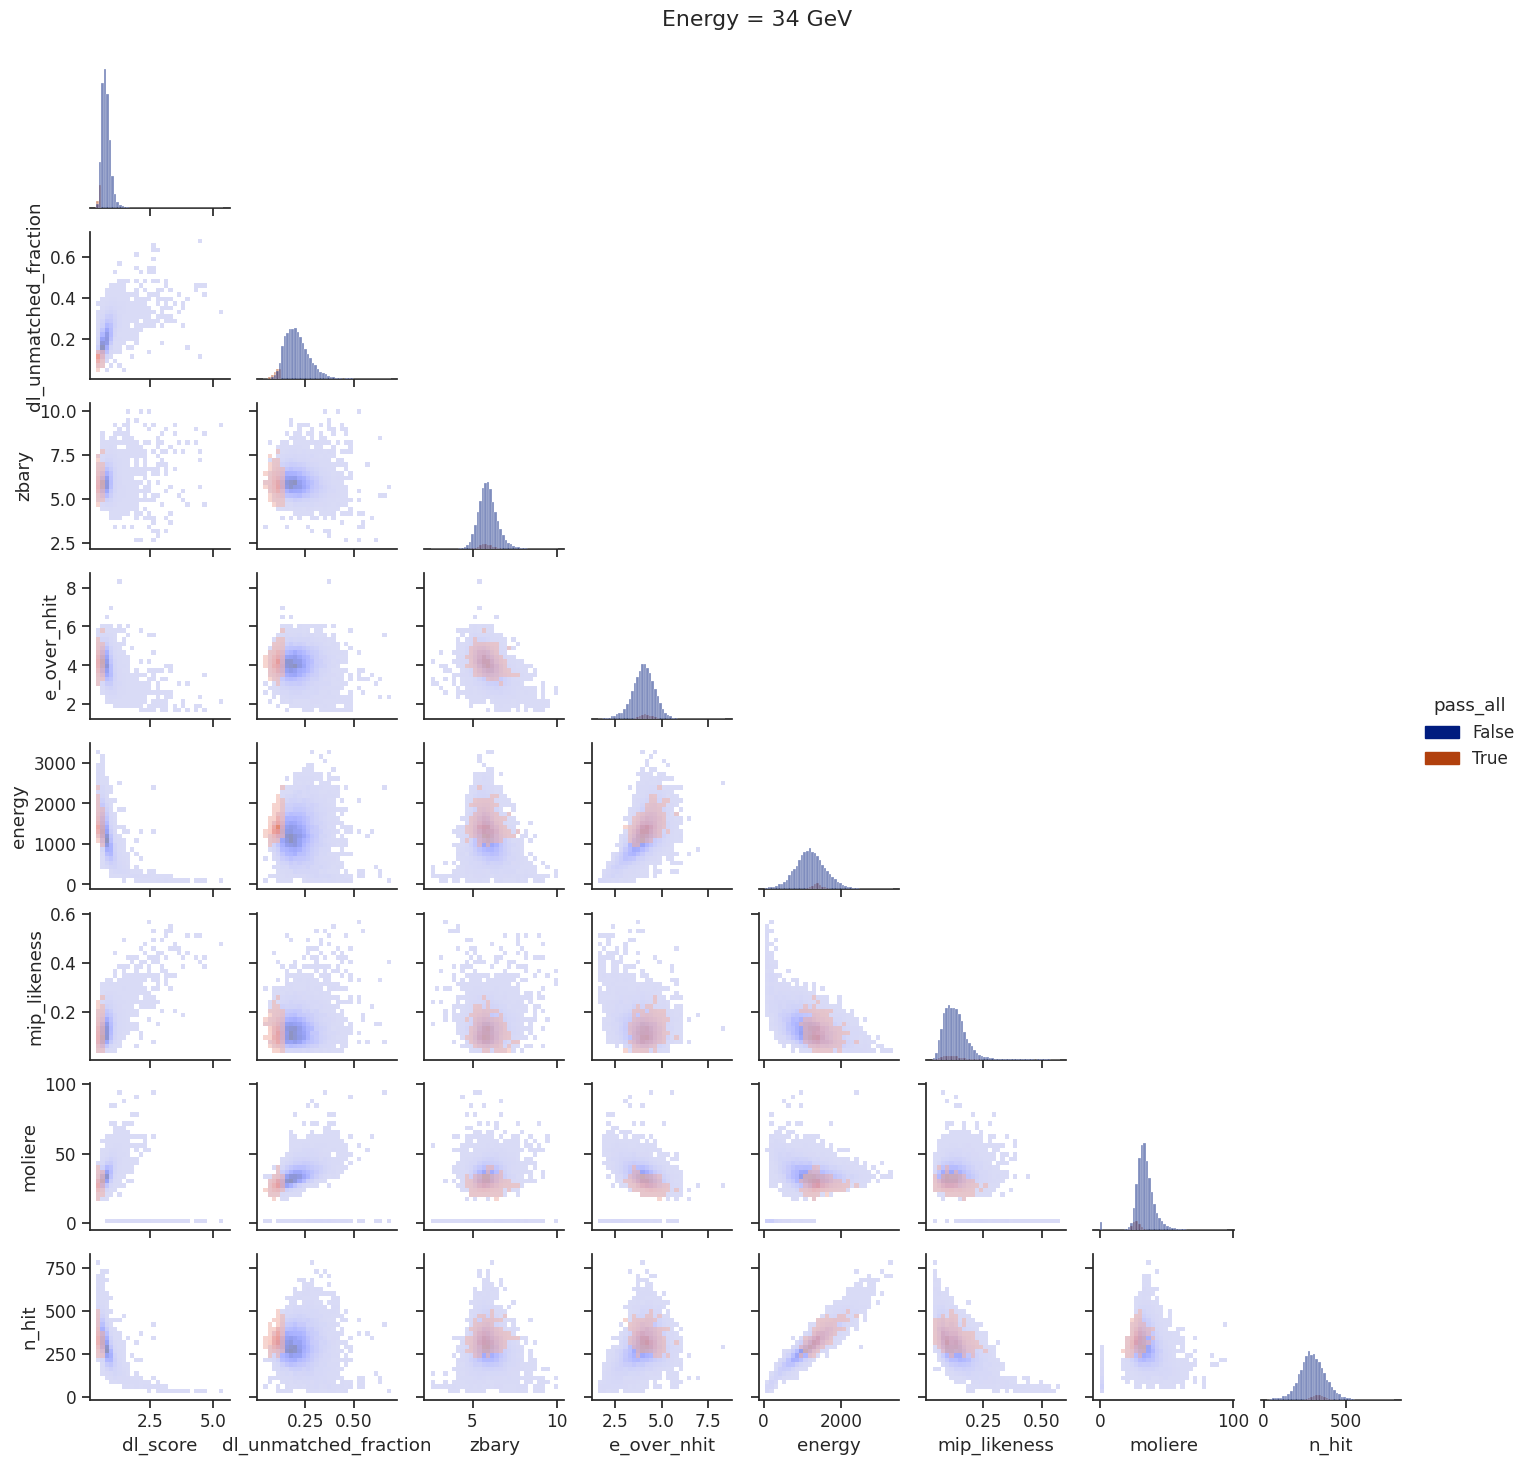

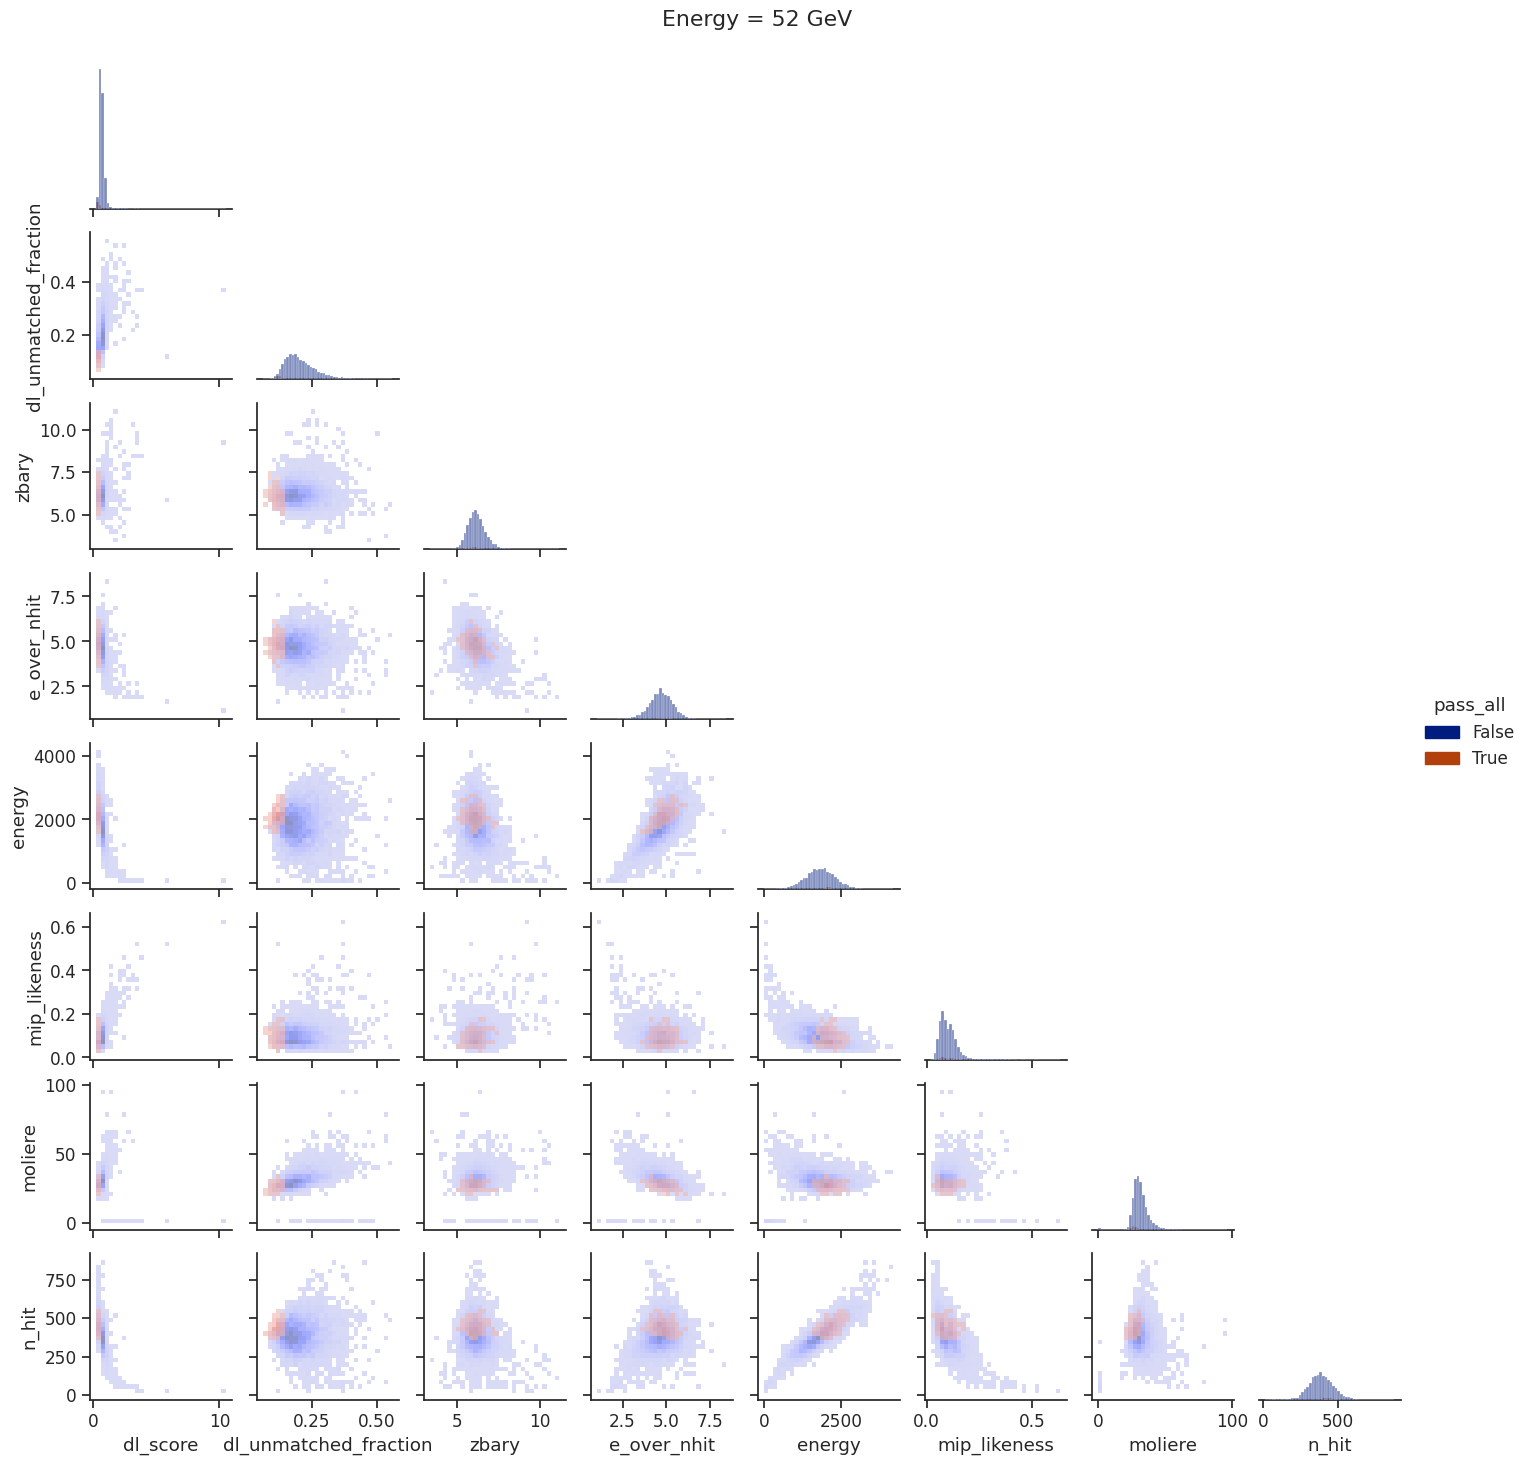

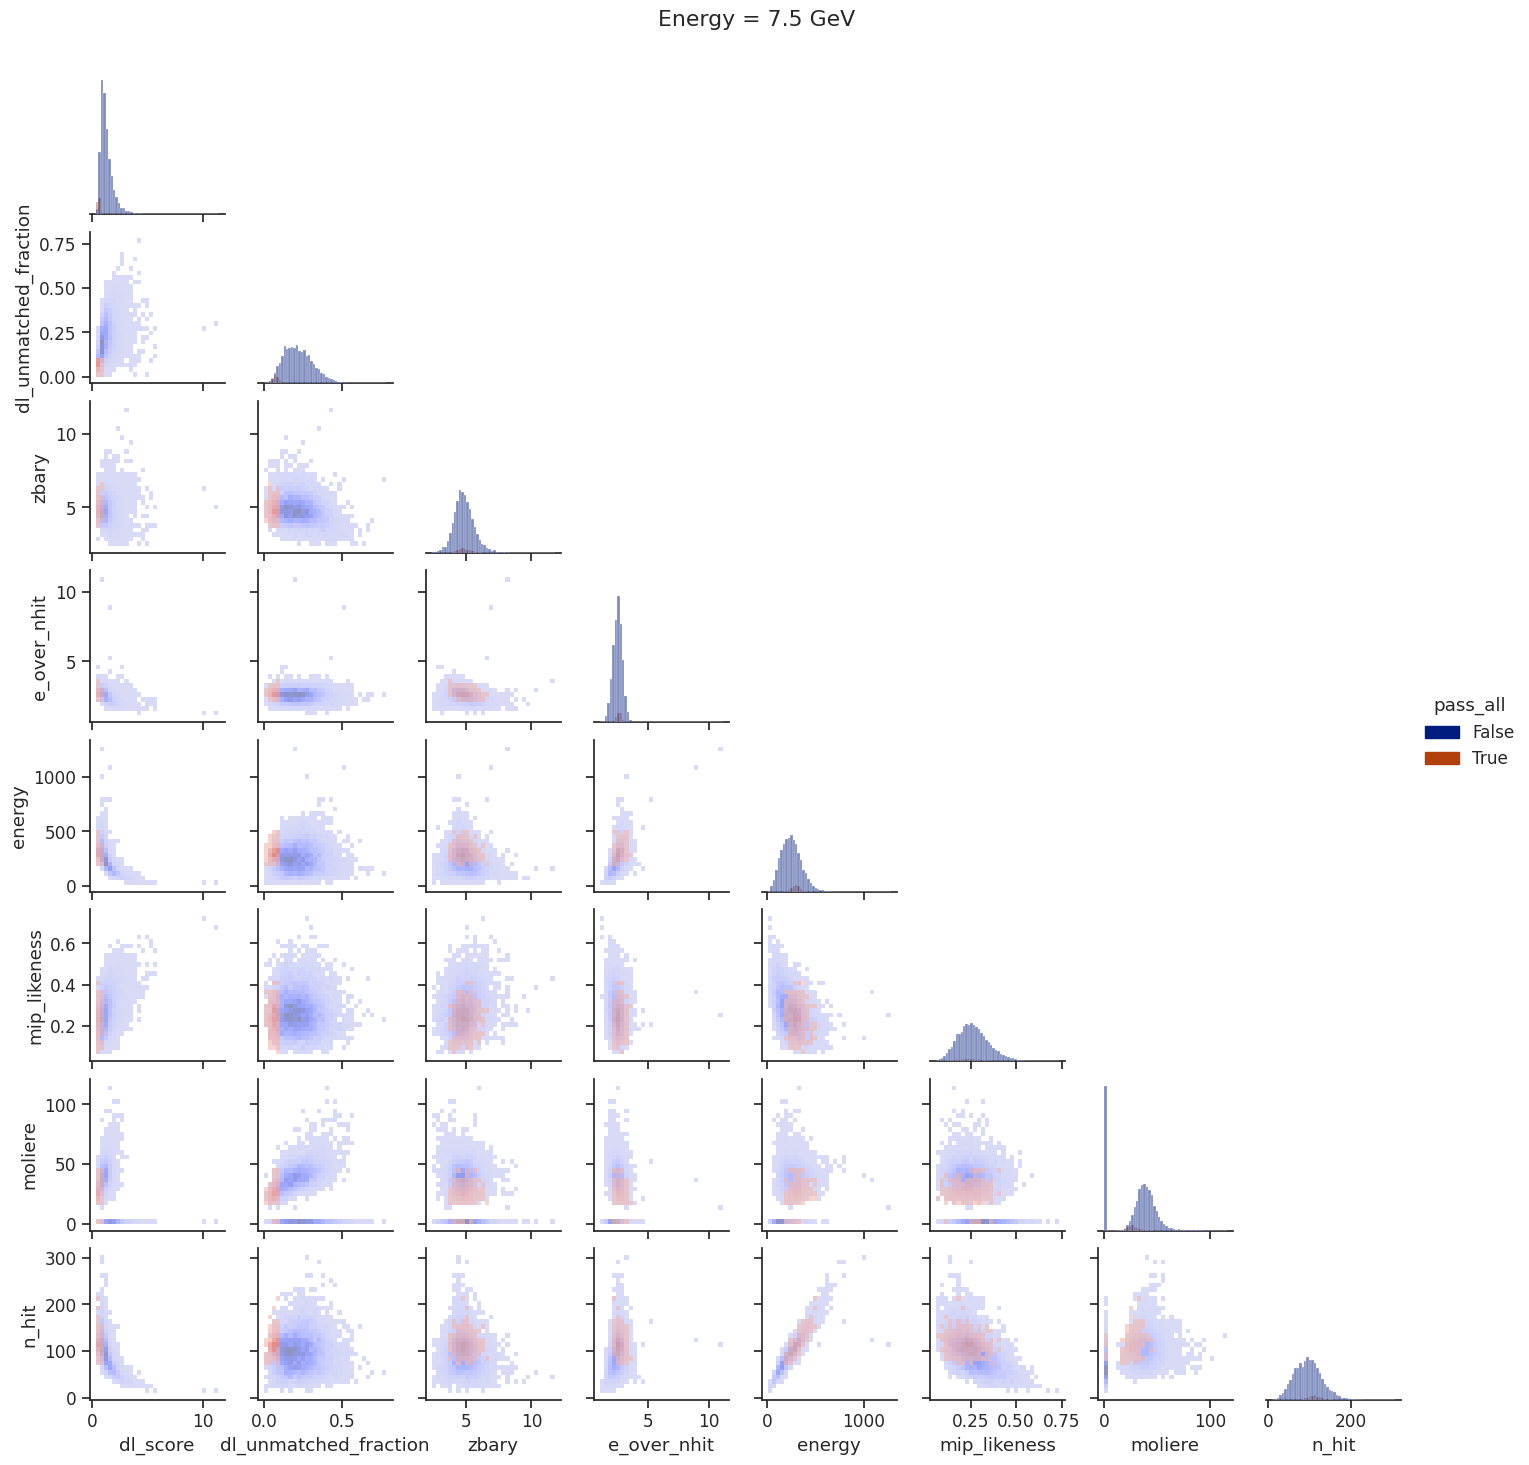

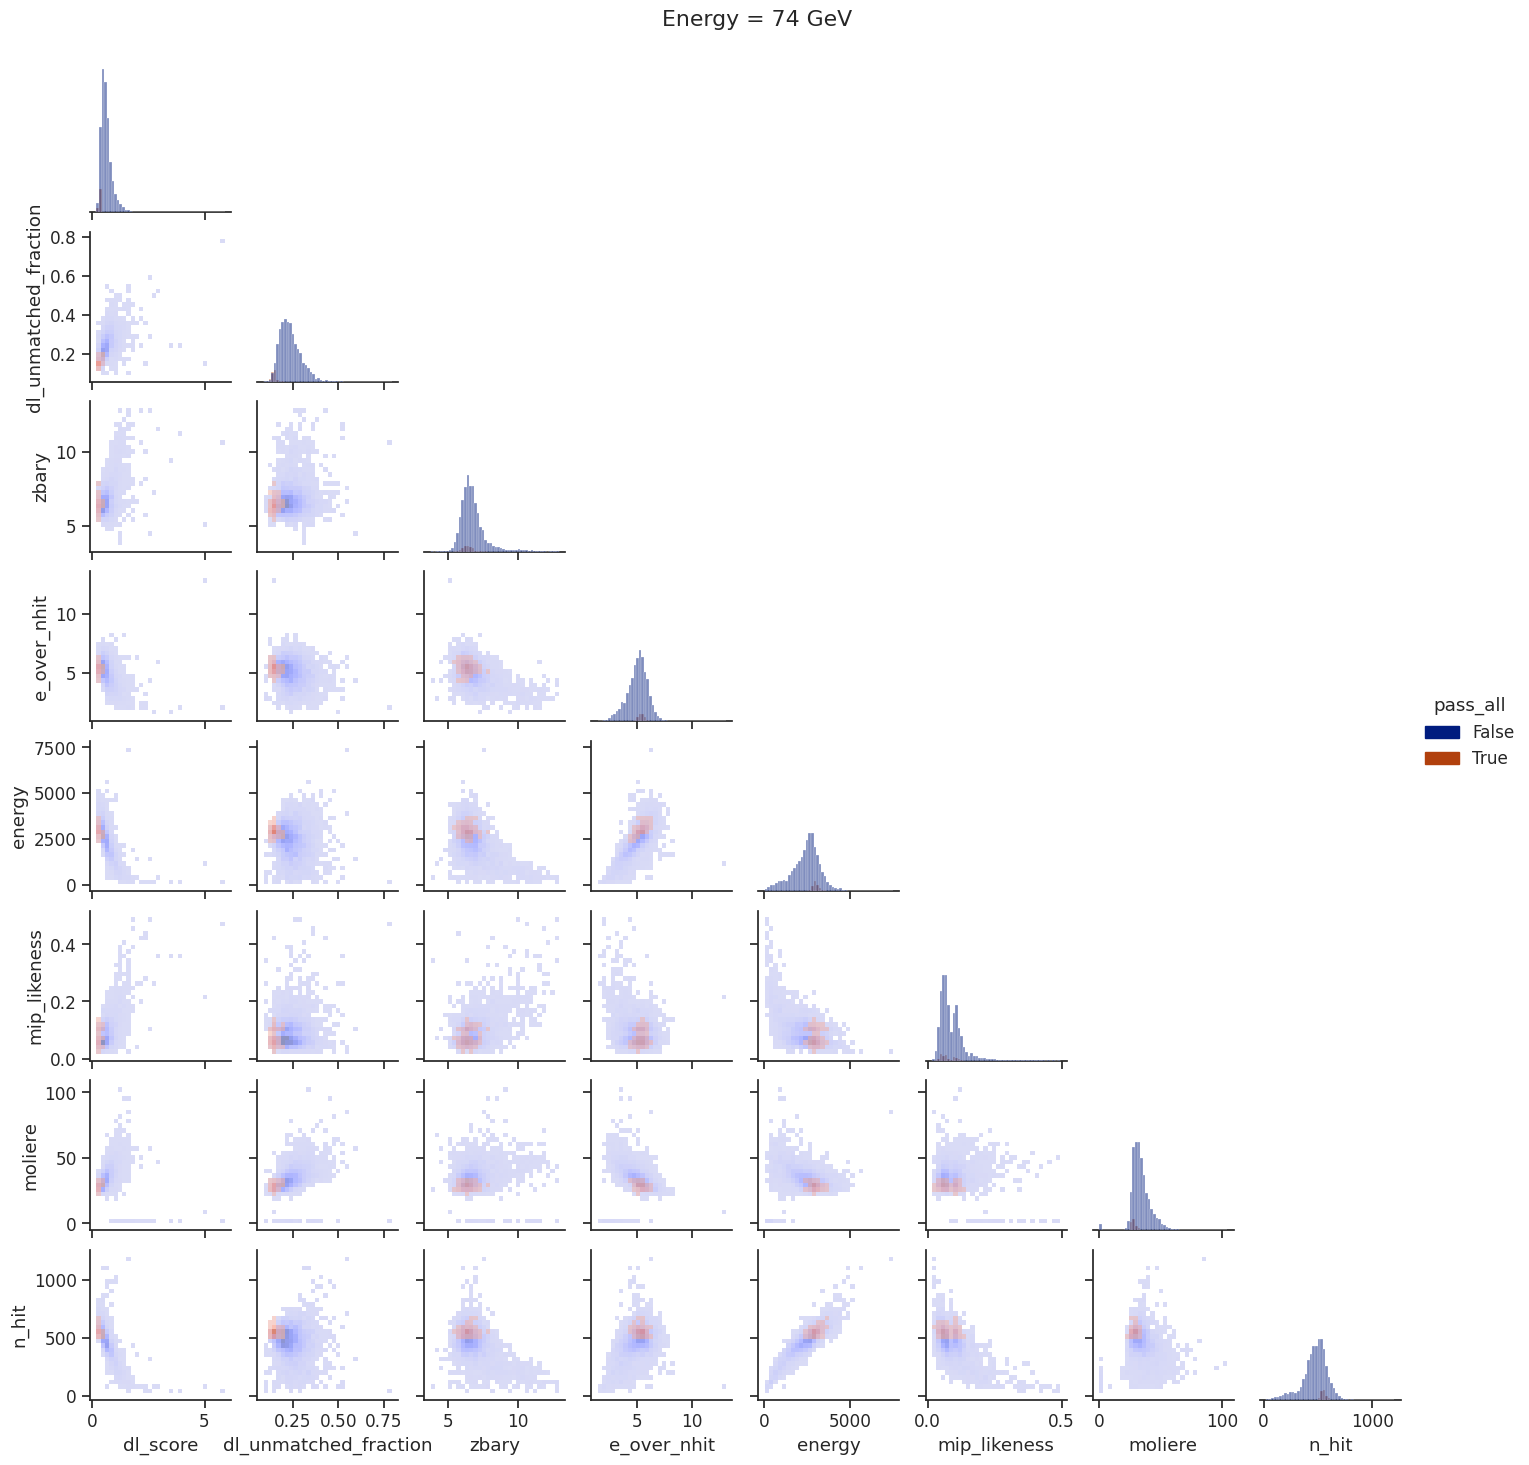

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="ticks", palette="dark", context="notebook", font_scale=1.1)
# sns.set_theme()
df_sample = df.sample(n=50_000, random_state=0)
plot_cols = df_sample.select_dtypes(include="number").columns
plot_cols = [c for c in plot_cols if c != "pass_all"]  # que no se repita como variable

for e in sorted(df_sample["energy_lbl"].unique()):
    df_e = df_sample[df_sample["energy_lbl"] == e]
    g = sns.pairplot(df_e, vars=plot_cols, hue="pass_all", kind="hist", corner=True,
                      plot_kws={"alpha": 0.6, "bins":30}, diag_kws={"bins":50},height=1.8)
    g.figure.suptitle(f"Energy = {e} GeV", y=1.02)
    plt.show()

In [ ]:
import numpy as np

corr = df_sample[plot_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

In [ ]:
for e in sorted(df_sample["energy_lbl"].unique()):
    df_e = df_sample[df_sample["energy_lbl"] == e]
    corr = df_e[plot_cols].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                square=True, linewidths=0.5)
    plt.title(f"Matriz de correlación — Energy = {e} GeV")
    plt.tight_layout()
    plt.show()

In [ ]:
for val in sorted(df_sample["pass_all"].unique()):
    df_p = df_sample[df_sample["pass_all"] == val]
    corr = df_p[plot_cols].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title(f"Matriz de correlación — pass_all = {val}")
    plt.tight_layout()
    plt.show()

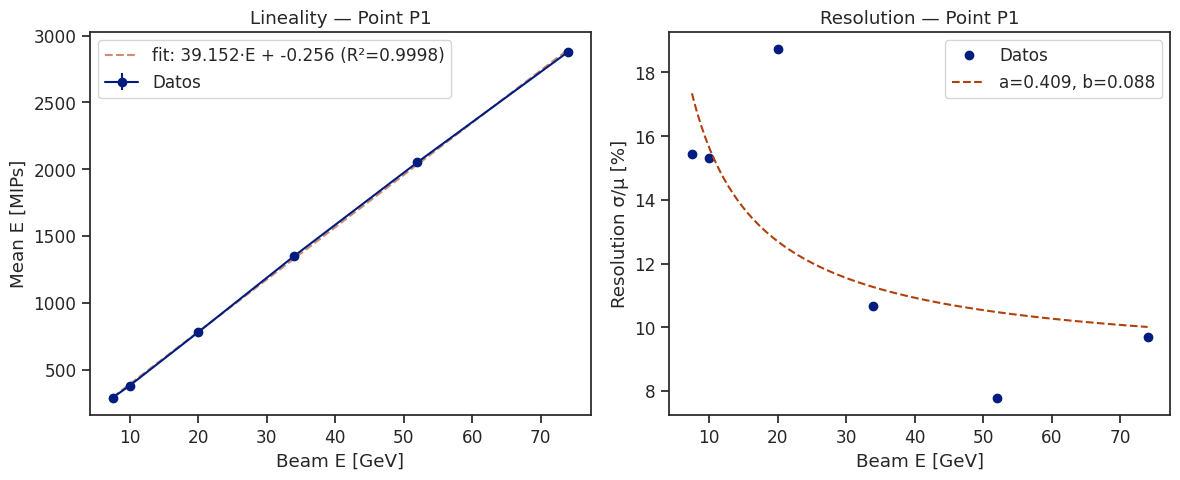

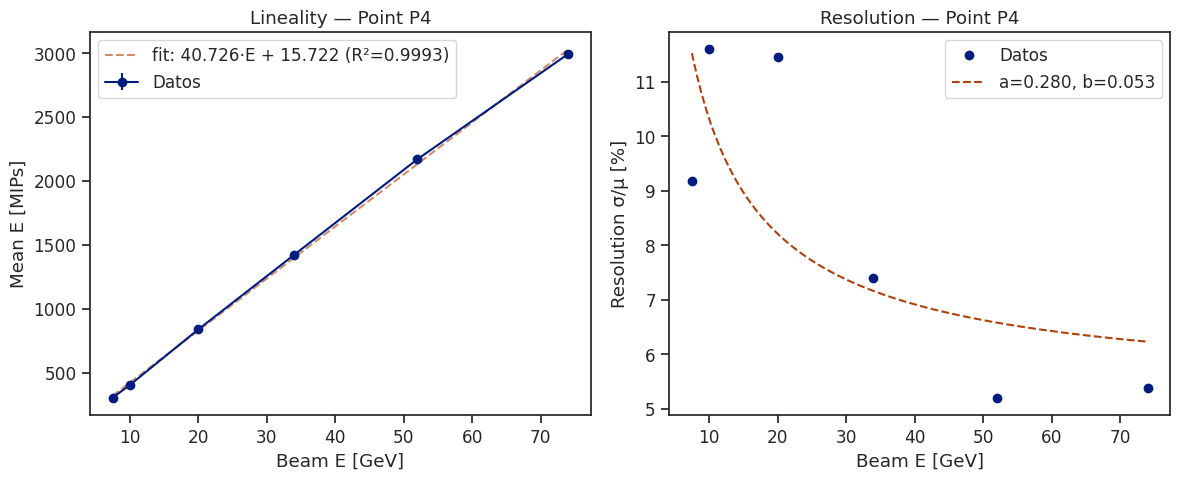

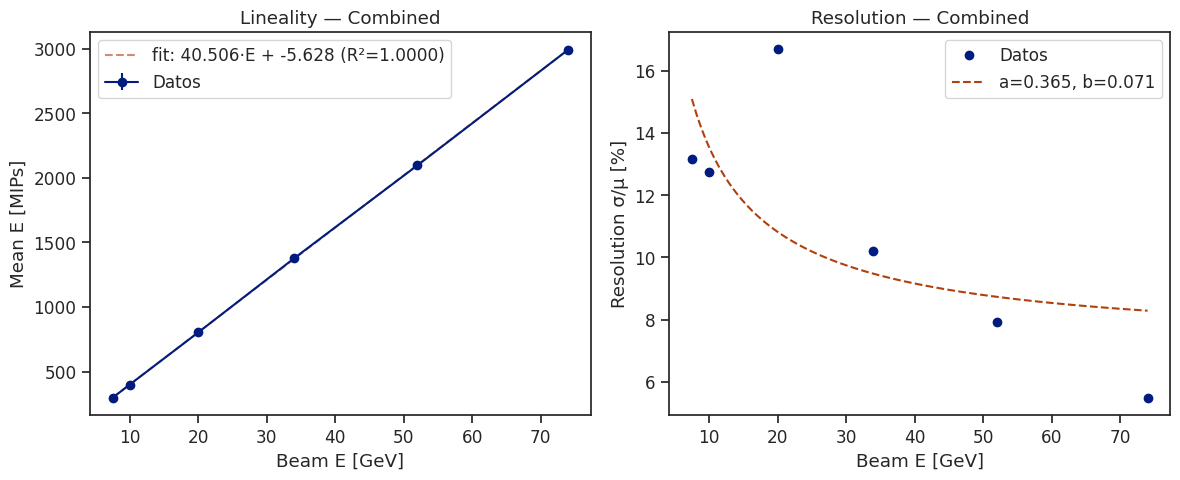

,energy_lbl,beam_energy,point,mean_mips,sigma_mips,resolution,n
8,7.5,7.5,P1,289.281924,44.654264,0.154362,9600
0,10,10.0,P1,380.295730,58.289577,0.153274,4958
2,20,20.0,P1,780.052219,146.052996,0.187235,12015
4,34,34.0,P1,1349.920441,143.828300,0.106546,22854
6,52,52.0,P1,2052.136583,159.833459,0.077886,5628
10,74,74.0,P1,2879.331660,278.883282,0.096857,245
9,7.5,7.5,P4,305.588821,28.062371,0.091830,4805
1,10,10.0,P4,404.194404,46.847531,0.115903,12876
3,20,20.0,P4,839.492556,96.134276,0.114515,4378
5,34,34.0,P4,1423.136779,105.190922,0.073915,8697


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def gauss(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

def fit_gaussian(data, nbins=100, n_iter=2, n_sigma=2):
    """Ajuste gaussiano iterativo (recorta colas) para mu/sigma robustos."""
    data = np.asarray(data)
    mu, sigma = np.mean(data), np.std(data)
    for _ in range(n_iter):
        mask = (data > mu - n_sigma*sigma) & (data < mu + n_sigma*sigma)
        d = data[mask]
        counts, edges = np.histogram(d, bins=nbins)
        centers = 0.5*(edges[:-1] + edges[1:])
        try:
            popt, _ = curve_fit(gauss, centers, counts, p0=[counts.max(), mu, sigma])
            mu, sigma = popt[1], abs(popt[2])
        except RuntimeError:
            break
    return mu, sigma

def linearity_resolution(df, energy_col="energy", filter_pass=True, use_gaussian_fit=True,
                          combined_label="combined"):
    d = df[df["pass_all"]] if (filter_pass and "pass_all" in df.columns) else df

    def _compute(group_cols, point_label_fn):
        rows = []
        for keys, g in d.groupby(group_cols):
            e_lbl = keys if not isinstance(keys, tuple) else keys[0]
            point = point_label_fn(keys)
            vals = g[energy_col].values
            mu, sigma = fit_gaussian(vals) if use_gaussian_fit else (np.mean(vals), np.std(vals))
            rows.append({
                "energy_lbl": e_lbl,
                "beam_energy": float(e_lbl),
                "point": point,
                "mean_mips": mu,
                "sigma_mips": sigma,
                "resolution": sigma / mu,
                "n": len(vals),
            })
        return rows

    # por punto
    rows_per_point = _compute(["energy_lbl", "point"], lambda k: k[1])
    # combinado (ignorando point)
    rows_combined = _compute(["energy_lbl"], lambda k: combined_label)

    res_df = pd.DataFrame(rows_per_point + rows_combined)
    return res_df.sort_values(["point", "beam_energy"])
def r_squared(y_true, y_pred):
    y_true = np.asarray(y_true)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot
def plot_linearity_resolution(res_df, points=None, combined_label="combined"):
    """Genera una figura (linealidad+resolución) por cada punto en `points`,
    incluyendo la versión combinada si está en res_df."""
    if points is None:
        points = list(res_df["point"].unique())

    def res_func(E, a, b):
        return np.sqrt((a/np.sqrt(E))**2 + b**2)

    for p in points:
        sub = res_df[res_df["point"] == p].sort_values("beam_energy")
        if sub.empty:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        title_suffix = "Combined" if p == combined_label else f"Point {p}"

        # --- Linealidad ---
        axes[0].errorbar(sub["beam_energy"], sub["mean_mips"],
                          yerr=sub["sigma_mips"]/np.sqrt(sub["n"]),
                          marker="o", label="Datos")
        fit = np.polyfit(sub["beam_energy"], sub["mean_mips"], 1)
        y_pred = np.polyval(fit, sub["beam_energy"])
        r2 = r_squared(sub["mean_mips"], y_pred)
        x_fit = np.linspace(sub["beam_energy"].min(), sub["beam_energy"].max(), 100)
        axes[0].plot(x_fit, np.polyval(fit, x_fit), "--", alpha=0.6,
                     label=f"fit: {fit[0]:.3f}·E + {fit[1]:.3f} (R²={r2:.4f})")
        axes[0].set_xlabel("Beam E [GeV]")
        axes[0].set_ylabel("Mean E [MIPs]")
        axes[0].set_title(f"Lineality — {title_suffix}")
        axes[0].legend()
        # --- Resolución ---
        axes[1].plot(sub["beam_energy"], sub["resolution"]*100, "o", label="Datos")
        try:
            popt, _ = curve_fit(res_func, sub["beam_energy"], sub["resolution"], p0=[0.2, 0.02])
            x_fit = np.linspace(sub["beam_energy"].min(), sub["beam_energy"].max(), 100)
            axes[1].plot(x_fit, res_func(x_fit, *popt)*100, "--",
                         label=f"a={popt[0]:.3f}, b={popt[1]:.3f}")
        except RuntimeError:
            pass
        axes[1].set_xlabel("Beam E [GeV]")
        axes[1].set_ylabel("Resolution σ/μ [%]")
        axes[1].set_title(f"Resolution — {title_suffix}")
        axes[1].legend()

        plt.tight_layout()
        plt.show()


res_df = linearity_resolution(df)
plot_linearity_resolution(res_df)   # genera 3 figuras: P1, P4, combined (o los puntos que tengas)
res_df